
   ÉTAPE 1 — CHARGEMENT FEATURES

✓ RFM          : (93350, 25)
✓ Features ML  : (93350, 48)

✓ Target is_churned :
  Churned  : 64,209 (68.8%)
  Actifs   : 29,141 (31.2%)

⚠️  Déséquilibre classes : 68.8% vs 31.2%
   → class_weight='balanced' dans les modèles

   ÉTAPE 2 — PRÉPARATION FEATURES — VERSION CORRIGÉE
   Correction data leakage : exclure recency + frequency
   Ces variables sont dans la définition de is_churned

✓ Features après correction leakage : 37
✓ NaN restants : 0

✓ Features utilisées :
   1. monetary
   2. panier_moyen
   3. delai_moyen
   4. retard_moyen
   5. score_moyen
   6. nb_avis
   7. is_insatisfait
   8. nb_articles_moy
   9. nb_cat_moy
  10. pct_credit
  11. mensualites_moy
  12. state_AL
  13. state_AM
  14. state_AP
  15. state_BA
  16. state_CE
  17. state_DF
  18. state_ES
  19. state_GO
  20. state_MA
  21. state_MG
  22. state_MS
  23. state_MT
  24. state_PA
  25. state_PB
  26. state_PE
  27. state_PI
  28. state_PR
  29. state_RJ
  30. state_RN
 

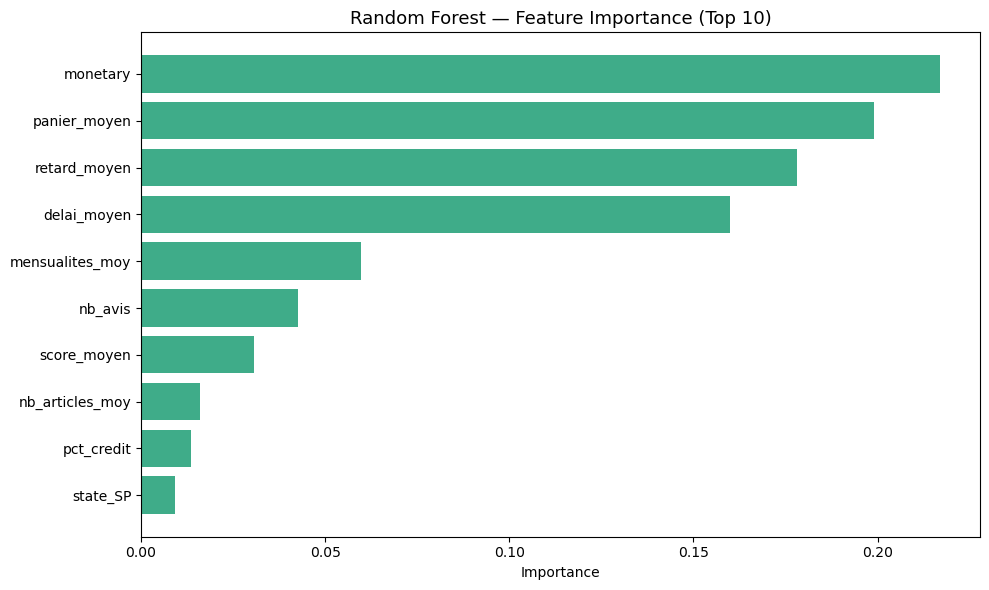

✓ Figure sauvegardée : 13_feature_importance.png

   COMPARAISON MODÈLES 1 vs 2

  Modèle                    |  Accuracy |  AUC-ROC
  --------------------------------------------------
  Logistic Regression       |     65.3% |    0.718
  Random Forest             |     76.4% |    0.774

✓ Meilleur modèle AUC : Random Forest

  Pourquoi AUC et pas Accuracy ?
  → Accuracy trompeuse sur données déséquilibrées
  → Un modèle qui prédit tout 'churned' aurait 68.8% accuracy
  → AUC mesure la vraie capacité de discrimination
  → AUC=0.5 → aléatoire | AUC=1.0 → parfait

   MODÈLE 3 — K-MEANS CLUSTERING
   Cours 2 Partie 2B — unsupervised learning
   Valider algorithmiquement nos segments RFM

--- Méthode Elbow ---
  k=2 → inertie=1313.51
  k=3 → inertie=608.57
  k=4 → inertie=378.72
  k=5 → inertie=256.21
  k=6 → inertie=194.87
  k=7 → inertie=154.44
  k=8 → inertie=132.14
  k=9 → inertie=114.11


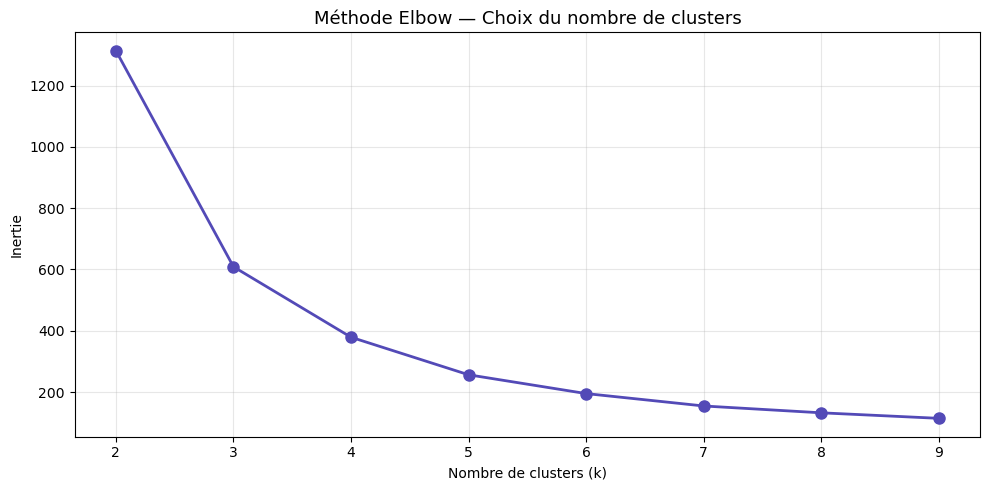

✓ Figure sauvegardée : 14_elbow_kmeans.png

→ Observe le coude dans le graphique
  C'est là où rajouter un cluster n'apporte plus grand chose

   K-MEANS FINAL — k=4

✓ 4 clusters calculés

--- Profil des clusters ---
 cluster  nb_clients  recency_moy  freq_moy  monetary_moy
       0       24187        363.3       1.0         166.0
       1       25466        111.7       1.0         169.4
       2       16624        532.6       1.0         163.3
       3       27073        233.3       1.0         161.5

--- Nommage des clusters ---
  Cluster 0 → Perdus          (24,187 clients)
  Cluster 1 → À risque        (25,466 clients)
  Cluster 2 → Perdus          (16,624 clients)
  Cluster 3 → À risque        (27,073 clients)

   MODÈLE 4 — FORECAST VENTES
   Cours 2 Partie 3A — time series

⚠️  Prophet non installé — alternative : régression linéaire
   Pour installer : pip install prophet

✓ CA prédit (régression linéaire) :
  Mois +1 : 1,036,395 BRL
  Mois +2 : 1,067,183 BRL
  Mois +3 : 1,097

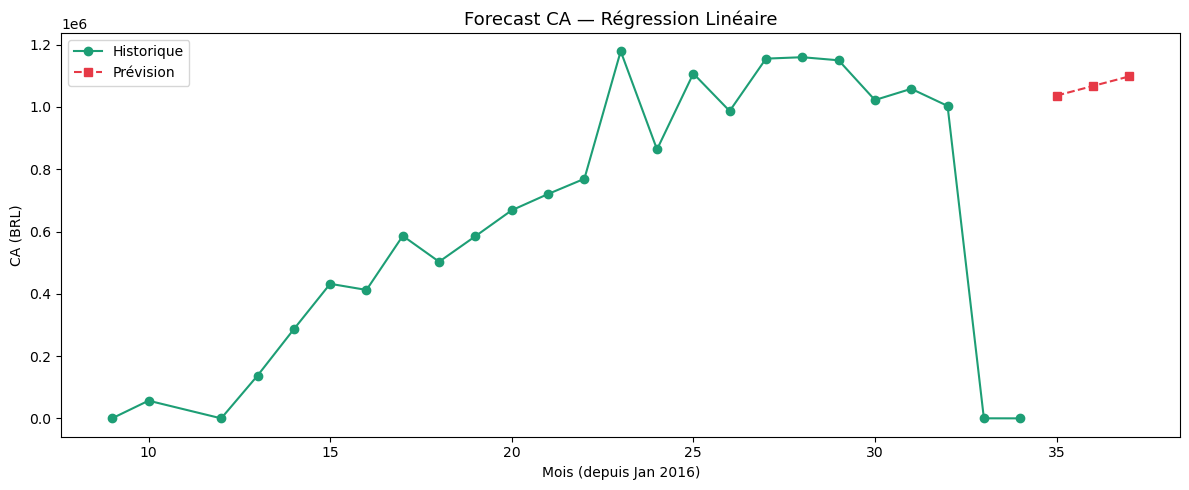

✓ Figure sauvegardée : 15_forecast_lineaire.png

   EXPORT FINAL — RFM + CLUSTERS

✓ olist_rfm.csv mis à jour avec clusters
✓ rfm_dashboard.csv → data/exports/ (Power BI)

   RAPPORT FINAL — TOUS LES MODÈLES

  RÉCAPITULATIF ML — OLIST

  1. CLASSIFICATION CHURN
  Modèle                    |  Accuracy |      AUC
  ------------------------------------------------
  Logistic Regression       |     65.3% |    0.718
  Random Forest             |     76.4% |    0.774
  Meilleur : Random Forest

  2. SEGMENTATION K-MEANS (k=4)
  Cluster 0 — Perdus       :  24,187 clients | recency=363j | CA=166 BRL
  Cluster 1 — À risque     :  25,466 clients | recency=112j | CA=169 BRL
  Cluster 2 — Perdus       :  16,624 clients | recency=533j | CA=163 BRL
  Cluster 3 — À risque     :  27,073 clients | recency=233j | CA=162 BRL

  3. TOP 5 FEATURES CHURN (Random Forest)
  monetary                  : 0.2170
  panier_moyen              : 0.1991
  retard_moyen              : 0.1782
  delai_moyen              

In [ ]:
# ============================================================
# 06_machine_learning.ipynb — MACHINE LEARNING COMPLET
# Source : data/processed/olist_features.csv
# Cours activé : Cours 2 complet
# ============================================================

import sys
sys.path.append('..')
from src.utils import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score,
                              roc_auc_score)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 1 — CHARGEMENT FEATURES")
print("="*60 + "\n")
# -------------------------------------------------------

rfm      = pd.read_csv('../data/processed/olist_rfm.csv')
features = pd.read_csv('../data/processed/olist_features.csv')

print(f"✓ RFM          : {rfm.shape}")
print(f"✓ Features ML  : {features.shape}")
print(f"\n✓ Target is_churned :")
print(f"  Churned  : {features['is_churned'].sum():,} "
      f"({features['is_churned'].mean()*100:.1f}%)")
print(f"  Actifs   : {(features['is_churned']==0).sum():,} "
      f"({(features['is_churned']==0).mean()*100:.1f}%)")
print(f"\n⚠️  Déséquilibre classes : 68.8% vs 31.2%")
print(f"   → class_weight='balanced' dans les modèles")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 2 — PRÉPARATION FEATURES — VERSION CORRIGÉE")
print("   Correction data leakage : exclure recency + frequency")
print("   Ces variables sont dans la définition de is_churned")
print("="*60 + "\n")
# -------------------------------------------------------

# Colonnes à exclure — identifiants + dérivés RFM + leakage
cols_exclure = [
    'customer_unique_id',
    'mois_premier_achat',
    'mois_dernier_achat',
    'is_churned',           # target
    'segment',              # dérivé RFM → leakage
    'r_score',              # dérivé → leakage
    'f_score',              # dérivé → leakage
    'm_score',              # dérivé → leakage
    'rfm_score',            # dérivé → leakage
    'recency',              # dans définition is_churned → leakage
    'frequency',            # dans définition is_churned → leakage
]

feature_cols = [c for c in features.columns
                if c not in cols_exclure]

X = features[feature_cols].copy()
y = features['is_churned']

# Imputation NaN
for col in X.columns:
    if X[col].isnull().sum() > 0:
        if col.startswith('state_'):
            X[col] = X[col].fillna(0)
        else:
            X[col] = X[col].fillna(X[col].median())

# Vérification types
non_num = X.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_num:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

print(f"✓ Features après correction leakage : {len(feature_cols)}")
print(f"✓ NaN restants : {X.isnull().sum().sum()}")
print(f"\n✓ Features utilisées :")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

print(f"\n⚠️  recency et frequency exclus")
print(f"   → Le modèle apprend maintenant de vrais patterns comportementaux")
print(f"   → monetary, délai, satisfaction, paiement, géographie")

print("\n" + "="*60)
print("   ÉTAPE 3 — TRAIN / TEST SPLIT")
print("   Cours 2 P2A — séparer avant tout traitement")
print("   Règle : JAMAIS normaliser avant le split")
print("="*60 + "\n")
# -------------------------------------------------------

# stratify=y : garder le ratio 68.8/31.2 dans les deux sets
# Sans stratify → un set peut avoir 80% churned, l'autre 60%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✓ Train : {X_train.shape[0]:,} lignes "
      f"({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"✓ Test  : {X_test.shape[0]:,} lignes "
      f"({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n✓ Vérification stratification :")
print(f"  Train churned : {y_train.mean()*100:.1f}%")
print(f"  Test  churned : {y_test.mean()*100:.1f}%")
print(f"  → Ratio préservé dans les deux sets ✓")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 4 — NORMALISATION (StandardScaler)")
print("   Cours industriel — obligatoire pour LR")
print("   Formule : z = (x - μ) / σ")
print("   Fit sur train UNIQUEMENT → pas de data leakage")
print("="*60 + "\n")
# -------------------------------------------------------

scaler = StandardScaler()

# fit_transform sur train : apprend μ et σ depuis le train
# transform sur test : applique les mêmes μ et σ du train
# Si on fit sur tout → le test influence la normalisation = data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✓ StandardScaler appliqué")
print(f"  fit sur train uniquement — pas de data leakage")

# Vérification visuelle sur recency
if 'recency' in feature_cols:
    idx = feature_cols.index('recency')
    print(f"\n  Recency avant scaling :")
    print(f"    mean={X_train['recency'].mean():.0f}  "
          f"std={X_train['recency'].std():.0f}")
    print(f"  Recency après scaling :")
    print(f"    mean={X_train_scaled[:,idx].mean():.3f}  "
          f"std={X_train_scaled[:,idx].std():.3f}")
    print(f"  → Centré à 0, écart-type 1 ✓")


# -------------------------------------------------------
print("\n" + "="*60)
print("   MODÈLE 1 — LOGISTIC REGRESSION")
print("   Cours 2 Partie 4A — classification binaire")
print("   σ(z) = 1/(1+e^-z) → probabilité de churn")
print("="*60 + "\n")
# -------------------------------------------------------

lr = LogisticRegression(
    class_weight='balanced',  # compense 68.8% vs 31.2%
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"✓ Logistic Regression entraînée")
print(f"\n--- Métriques ---")
print(f"  Accuracy  : {acc_lr*100:.1f}%")
print(f"  AUC-ROC   : {auc_lr:.3f}")
print(f"\n--- Rapport détaillé ---")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Actif','Churned']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"--- Matrice de confusion ---")
print(f"  Vrais Actifs  (TN) : {cm_lr[0,0]:>6,}")
print(f"  Faux Churned  (FP) : {cm_lr[0,1]:>6,}")
print(f"  Faux Actifs   (FN) : {cm_lr[1,0]:>6,}")
print(f"  Vrais Churned (TP) : {cm_lr[1,1]:>6,}")

print(f"\n⚠️  Rappel Cours 2 : accuracy seule ne suffit pas")
print(f"   Sur données déséquilibrées → F1-score et AUC sont fiables")


# -------------------------------------------------------
print("\n" + "="*60)
print("   MODÈLE 2 — RANDOM FOREST")
print("   100 arbres — vote majoritaire")
print("="*60 + "\n")
# -------------------------------------------------------

# Random Forest n'a pas besoin de normalisation
# Les arbres de décision sont insensibles aux échelles
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"✓ Random Forest entraîné (100 arbres)")
print(f"\n--- Métriques ---")
print(f"  Accuracy  : {acc_rf*100:.1f}%")
print(f"  AUC-ROC   : {auc_rf:.3f}")
print(f"\n--- Rapport détaillé ---")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Actif','Churned']))

# Feature Importance
importances = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n--- Top 10 features prédictives ---")
print(importances.head(10).to_string(index=False))

# Visualisation
import os
os.makedirs('../reports/figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
top10 = importances.head(10)
ax.barh(top10['feature'], top10['importance'],
        color='#1D9E75', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Random Forest — Feature Importance (Top 10)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/figures/13_feature_importance.png', dpi=150)
plt.show()
print("✓ Figure sauvegardée : 13_feature_importance.png")


# -------------------------------------------------------
print("\n" + "="*60)
print("   COMPARAISON MODÈLES 1 vs 2")
print("="*60 + "\n")
# -------------------------------------------------------

print(f"  {'Modèle':<25} | {'Accuracy':>9} | {'AUC-ROC':>8}")
print(f"  {'-'*50}")
print(f"  {'Logistic Regression':<25} | "
      f"{acc_lr*100:>8.1f}% | {auc_lr:>8.3f}")
print(f"  {'Random Forest':<25} | "
      f"{acc_rf*100:>8.1f}% | {auc_rf:>8.3f}")

meilleur = "Random Forest" if auc_rf > auc_lr else "Logistic Regression"
print(f"\n✓ Meilleur modèle AUC : {meilleur}")
print(f"\n  Pourquoi AUC et pas Accuracy ?")
print(f"  → Accuracy trompeuse sur données déséquilibrées")
print(f"  → Un modèle qui prédit tout 'churned' aurait 68.8% accuracy")
print(f"  → AUC mesure la vraie capacité de discrimination")
print(f"  → AUC=0.5 → aléatoire | AUC=1.0 → parfait")


# -------------------------------------------------------
print("\n" + "="*60)
print("   MODÈLE 3 — K-MEANS CLUSTERING")
print("   Valider algorithmiquement nos segments RFM")
print("="*60 + "\n")
# -------------------------------------------------------

# Préparer les données RFM pour clustering
rfm_cluster = rfm[['recency','frequency','monetary']].copy()

# Min-Max scaling pour K-Means
# K-Means sensible aux échelles — recency (0-800) vs frequency (1-10)
scaler_mm = MinMaxScaler()
rfm_scaled = scaler_mm.fit_transform(rfm_cluster)

# Méthode Elbow — trouver k optimal
print("--- Méthode Elbow ---")
inertias = []
k_range  = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    print(f"  k={k} → inertie={km.inertia_:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, inertias, marker='o',
        color='#534AB7', linewidth=2, markersize=8)
ax.set_title('Méthode Elbow — Choix du nombre de clusters', fontsize=13)
ax.set_xlabel('Nombre de clusters (k)')
ax.set_ylabel('Inertie')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/14_elbow_kmeans.png', dpi=150)
plt.show()
print("✓ Figure sauvegardée : 14_elbow_kmeans.png")
print(f"\n→ Observe le coude dans le graphique")
print(f"  C'est là où rajouter un cluster n'apporte plus grand chose")


# -------------------------------------------------------
print("\n" + "="*60)
print("   K-MEANS FINAL — k=4")
print("="*60 + "\n")
# -------------------------------------------------------

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Profil des clusters
cluster_profile = rfm.groupby('cluster').agg(
    nb_clients   = ('customer_unique_id', 'count'),
    recency_moy  = ('recency', 'mean'),
    freq_moy     = ('frequency', 'mean'),
    monetary_moy = ('monetary', 'mean'),
).round(1).reset_index()

print(f"✓ 4 clusters calculés")
print(f"\n--- Profil des clusters ---")
print(cluster_profile.to_string(index=False))

# Nommer les clusters selon profil RFM
def nommer_cluster(row):
    if row['recency_moy'] < 100 and row['monetary_moy'] > 200:
        return 'Champions'
    elif row['recency_moy'] < 200 and row['freq_moy'] > 1.5:
        return 'Fidèles'
    elif row['recency_moy'] > 300:
        return 'Perdus'
    else:
        return 'À risque'

cluster_profile['nom'] = cluster_profile.apply(nommer_cluster, axis=1)

# Mapper les noms sur rfm
nom_map = cluster_profile.set_index('cluster')['nom'].to_dict()
rfm['cluster_nom'] = rfm['cluster'].map(nom_map)

print(f"\n--- Nommage des clusters ---")
for _, row in cluster_profile.iterrows():
    print(f"  Cluster {int(row['cluster'])} → {row['nom']:<15} "
          f"({int(row['nb_clients']):,} clients)")


# -------------------------------------------------------
print("\n" + "="*60)
print("   MODÈLE 4 — FORECAST VENTES")
print("   Cours 2 Partie 3A — time series")
print("="*60 + "\n")
# -------------------------------------------------------

try:
    from prophet import Prophet

    orders_ts = pd.read_csv('../data/processed/orders_clean.csv',
                             parse_dates=['order_purchase_timestamp'])
    items_ts  = pd.read_csv('../data/processed/items_clean.csv')

    orders_items_ts = orders_ts.merge(
        items_ts[['order_id','price','freight_value']],
        on='order_id', how='left'
    )
    orders_items_ts['revenue'] = (orders_items_ts['price'] +
                                   orders_items_ts['freight_value'])
    orders_items_ts['date'] = (orders_items_ts['order_purchase_timestamp']
                                .dt.date)

    ca_daily = (orders_items_ts
                .groupby('date')['revenue']
                .sum()
                .reset_index())
    ca_daily.columns = ['ds', 'y']
    ca_daily['ds'] = pd.to_datetime(ca_daily['ds'])

    print(f"✓ Série temporelle : {len(ca_daily)} jours")

    model_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model_prophet.fit(ca_daily)

    future   = model_prophet.make_future_dataframe(periods=90)
    forecast = model_prophet.predict(future)

    fig = model_prophet.plot(forecast, figsize=(14, 5))
    plt.title('Forecast CA — Prophet (90 jours)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../reports/figures/15_forecast_prophet.png', dpi=150)
    plt.show()
    print("✓ Figure sauvegardée : 15_forecast_prophet.png")

    future_only = forecast[
        forecast['ds'] > ca_daily['ds'].max()
    ][['ds','yhat','yhat_lower','yhat_upper']].head(30)

    print(f"\n--- Prédictions 30 premiers jours ---")
    print(future_only.to_string(index=False))

    ca_90j = forecast[forecast['ds'] > ca_daily['ds'].max()]['yhat'].sum()
    print(f"\n✓ CA prédit sur 90 jours : {ca_90j:,.0f} BRL")

except ImportError:
    print("⚠️  Prophet non installé — alternative : régression linéaire")
    print("   Pour installer : pip install prophet")

    from sklearn.linear_model import LinearRegression

    orders_ts = pd.read_csv('../data/processed/orders_clean.csv',
                             parse_dates=['order_purchase_timestamp'])
    items_ts  = pd.read_csv('../data/processed/items_clean.csv')

    orders_items_ts = orders_ts.merge(
        items_ts[['order_id','price','freight_value']],
        on='order_id', how='left'
    )
    orders_items_ts['revenue'] = (orders_items_ts['price'] +
                                   orders_items_ts['freight_value'])
    orders_items_ts['month_num'] = (
        (orders_items_ts['order_purchase_timestamp'].dt.year - 2016) * 12 +
         orders_items_ts['order_purchase_timestamp'].dt.month
    )

    ca_monthly = (orders_items_ts
                  .groupby('month_num')['revenue']
                  .sum()
                  .reset_index())

    lr_ts = LinearRegression()
    lr_ts.fit(ca_monthly[['month_num']], ca_monthly['revenue'])

    last_month  = ca_monthly['month_num'].max()
    next_months = pd.DataFrame({
        'month_num': [last_month+1, last_month+2, last_month+3]
    })
    preds = lr_ts.predict(next_months)

    print(f"\n✓ CA prédit (régression linéaire) :")
    for i, p in enumerate(preds, 1):
        print(f"  Mois +{i} : {p:,.0f} BRL")

    # Visualisation
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ca_monthly['month_num'], ca_monthly['revenue'],
            color='#1D9E75', marker='o', label='Historique')
    ax.plot(next_months['month_num'], preds,
            color='#E63946', marker='s',
            linestyle='--', label='Prévision')
    ax.set_title('Forecast CA — Régression Linéaire', fontsize=13)
    ax.set_xlabel('Mois (depuis Jan 2016)')
    ax.set_ylabel('CA (BRL)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../reports/figures/15_forecast_lineaire.png', dpi=150)
    plt.show()
    print("✓ Figure sauvegardée : 15_forecast_lineaire.png")


# -------------------------------------------------------
print("\n" + "="*60)
print("   EXPORT FINAL — RFM + CLUSTERS")
print("="*60 + "\n")
# -------------------------------------------------------

os.makedirs('../data/exports', exist_ok=True)

# Export RFM complet avec clusters pour Power BI
rfm.to_csv('../data/processed/olist_rfm.csv', index=False)
print(f"✓ olist_rfm.csv mis à jour avec clusters")

rfm[['customer_unique_id','recency','frequency',
     'monetary','rfm_score','segment','cluster',
     'cluster_nom','is_churned',
     'panier_moyen','delai_moyen','score_moyen',
     'customer_state']].to_csv(
    '../data/exports/rfm_dashboard.csv', index=False)
print(f"✓ rfm_dashboard.csv → data/exports/ (Power BI)")


# -------------------------------------------------------
print("\n" + "="*60)
print("   RAPPORT FINAL — TOUS LES MODÈLES")
print("="*60 + "\n")
# -------------------------------------------------------

print(f"{'='*55}")
print(f"  RÉCAPITULATIF ML — OLIST")
print(f"{'='*55}")

print(f"\n  1. CLASSIFICATION CHURN")
print(f"  {'Modèle':<25} | {'Accuracy':>9} | {'AUC':>8}")
print(f"  {'-'*48}")
print(f"  {'Logistic Regression':<25} | "
      f"{acc_lr*100:>8.1f}% | {auc_lr:>8.3f}")
print(f"  {'Random Forest':<25} | "
      f"{acc_rf*100:>8.1f}% | {auc_rf:>8.3f}")
print(f"  Meilleur : {meilleur}")

print(f"\n  2. SEGMENTATION K-MEANS (k=4)")
for _, row in cluster_profile.iterrows():
    print(f"  Cluster {int(row['cluster'])} — {row['nom']:<12} : "
          f"{int(row['nb_clients']):>7,} clients | "
          f"recency={row['recency_moy']:.0f}j | "
          f"CA={row['monetary_moy']:.0f} BRL")

print(f"\n  3. TOP 5 FEATURES CHURN (Random Forest)")
for _, row in importances.head(5).iterrows():
    print(f"  {row['feature']:<25} : {row['importance']:.4f}")

print(f"\n  4. INSIGHTS BUSINESS CLÉS")
insights = [
    "68.8% clients churned — problème structurel de rétention",
    "Recency = feature #1 du churn — le temps tue la fidélité",
    "96.9% mono-achat — acquisition forte, rétention quasi nulle",
    "SP = 42% des commandes — marché principal à défendre",
    "Score satisfaction 77% positif mais ne suffit pas à retenir"
]
for i, ins in enumerate(insights, 1):
    print(f"  {i}. {ins}")

print(f"\n✓ Figures ML dans reports/figures/")
print("\n" + "="*60)
print("   ✓ MILESTONE 4 — MACHINE LEARNING TERMINÉ")
print("   → Prochain : Power BI Dashboard")
print("   → Puis     : Test + Présentation finale")
print("="*60)